# 🚀 00: Foundations, Environment, and Benchmark Intake

*Part of the KV-Cache Eviction Capstone Series*
*Estimated time: 10–15 minutes*

---

Welcome! In this first notebook, we are going to establish an auditable, reproducible environment for the entire KV-cache eviction experiment. Before we measure performance or train policies, we must ensure our arithmetic is correct and our data is stable.

This notebook performs **Exploratory Data Analysis (EDA) only** on the canonical controlled retrieval corpus. It does not report eviction-quality results. You will need a GPU runtime; the code automatically adapts to a T4, RTX PRO 6000, or H100 and records the actual hardware profile used.

### Experiment Roadmap
```text
[GPU preflight] → [GQA formula gate] → [200-record controlled corpus] → [EDA artifacts]
```


## Step 1: Why Does This Matter?

If our cache-memory arithmetic is wrong, our entire budget-versus-quality comparison is invalid. If our benchmark datasets shift under us, our results cannot be reproduced.

This step locks down the environment. Our **acceptance criteria** are strict:
1. Pinned package versions, model revisions, and benchmark revisions must be explicitly recorded.
2. A measured cache payload must match our closed-form GQA-aware formula exactly (within a small structural tolerance).
3. The controlled corpus must contain exactly 200 records: 50 at each planned length, with a 30/10/10 train/validation/test split inside every length stratum.
4. Every record must retain prompt, answer, answer-location, seed, tokenizer-count, and provenance metadata.
5. No model quality, latency, or compression outcomes may be fabricated—if a test cannot run, it must be recorded as skipped.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
NOTEBOOK_ID = '00_foundations_environment_eda'
REQUESTED_PROFILE = 't4'

# Colab bootstrap: install pinned dependencies and unpack the shared core.
# Upload kvcore_bundle.zip supplied with this notebook suite if kvcore is not present.
from pathlib import Path
import sys, subprocess, zipfile

PINNED = [
    'transformers==4.56.2', 'accelerate==1.10.1', 'datasets==4.0.0',
    'huggingface_hub==0.34.4', 'bitsandbytes==0.47.0', 'safetensors==0.6.2',
    'sentencepiece==0.2.1', 'scipy==1.16.1', 'matplotlib==3.10.6',
    'seaborn==0.13.2', 'pandas==2.3.2',
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *PINNED])

if not Path('kvcore').exists():
    try:
        from google.colab import files
        print('Upload kvcore_bundle.zip from the delivered suite.')
        uploaded = files.upload()
        archive = next((Path(name) for name in uploaded if name.endswith('.zip')), None)
        if archive is None:
            raise FileNotFoundError('Please upload kvcore_bundle.zip.')
        with zipfile.ZipFile(archive) as zf:
            zf.extractall('.')
    except ImportError as error:
        raise RuntimeError('Run in Google Colab or place the kvcore directory beside this notebook.') from error

sys.path.insert(0, str(Path('.').resolve()))
from kvcore import *
from kvcore.config import BENCHMARKS, MODELS, POLICY_DEFAULTS, PROFILES, SUITE_VERSION
print({'suite_version': SUITE_VERSION, 'ruler_revision': BENCHMARKS['ruler']['revision'], 'longbench_revision': BENCHMARKS['longbench']['revision']})


Upload kvcore_bundle.zip from the delivered suite.


Saving kvcore_bundle.zip to kvcore_bundle.zip
{'suite_version': '2.1.0', 'ruler_revision': 'af56d31d700e6450edb8895278c7b6842fc5c505', 'longbench_revision': '5e628be450b7e67fb7ae6e201bd6d8f7056f7672'}


In [3]:
import json, os, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

REQUESTED_PROFILE = REQUESTED_PROFILE  # defined by the notebook title cell
NOTEBOOK_ID = globals().get('NOTEBOOK_ID', 'runtime')
set_all_seeds(590)
profile, runtime_status = select_profile(REQUESTED_PROFILE)
run_root = ensure_run_root(f'kv_eviction_{NOTEBOOK_ID}')
manifest = run_manifest(
    run_root,
    notebook=NOTEBOOK_ID,
    requested_profile=REQUESTED_PROFILE,
    active_profile=profile.name,
    model=model_spec(profile.model_tier),
    runtime_status=runtime_status,
)
print(json.dumps({'notebook': NOTEBOOK_ID, 'requested_profile': REQUESTED_PROFILE, 'active_profile': profile.name, 'runtime_status': runtime_status, 'run_root': str(run_root)}, indent=2))
if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU runtime is required for model execution. In Colab: Runtime > Change runtime type > GPU.')
print('GPU:', torch.cuda.get_device_name(0), 'VRAM GiB:', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2))


{
  "notebook": "00_foundations_environment_eda",
  "requested_profile": "t4",
  "active_profile": "t4",
  "runtime_status": {
    "requested_profile": "t4",
    "active_profile": "t4",
    "fallback": false,
    "reason": "matched",
    "gpu": {
      "name": "Tesla T4",
      "total_mib": 15360,
      "free_mib": 14910,
      "driver": "580.82.07"
    }
  },
  "run_root": "kv_eviction_00_foundations_environment_eda"
}
GPU: Tesla T4 VRAM GiB: 14.56


In [4]:
# Model and tokenizer are always loaded at immutable Hub revisions from kvcore.config.
# If the runtime is smaller than the requested tier, runtime_status records the fallback.
model, tokenizer = load_model_and_tokenizer(model_spec(profile.model_tier), load_mode=profile.load_mode, attn_implementation='sdpa')
print({'model': model.config._name_or_path, 'requested_profile': REQUESTED_PROFILE, 'active_profile': profile.name, 'load_mode': profile.load_mode})


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

{'model': 'Qwen/Qwen2.5-1.5B-Instruct', 'requested_profile': 't4', 'active_profile': 't4', 'load_mode': '4bit'}


## Step 2: GQA-Aware KV Accounting

Modern models use Grouped-Query Attention (GQA), which means there are fewer Key and Value heads than Query heads. Our cache formula must account for this exactly:

**Payload = layers × batch × retained tokens × KV heads × head dimension × 2 (K and V) × bytes per element**

Let us run a probe sequence through the model and verify that our formula matches the physical cache allocation.


In [5]:
from kvcore.accounting import formula_for_model, formula_gate
from kvcore.cache import prefill

probe = tokenizer('KV-cache accounting probe. ' * 32, return_tensors='pt').input_ids.to(next(model.parameters()).device)
cache, _ = prefill(model, probe, chunk_size=min(256, probe.shape[-1]), output_attentions=False)
expected = formula_for_model(model.config, retained_tokens=cache.physical_length, batch_size=1, dtype=next(model.parameters()).dtype)
gate = formula_gate(cache, expected['formula_bytes'], tolerance=0.02)
assert_formula_gate(gate)
write_json(run_root / 'checks' / 'kv_formula_gate.json', {'expected': expected, 'gate': gate})
print(json.dumps({'model_kv_spec': expected, 'gate': gate}, indent=2))


{
  "model_kv_spec": {
    "num_layers": 28,
    "num_attention_heads": 12,
    "num_key_value_heads": 2,
    "head_dim": 128,
    "bytes_per_element": 2,
    "sequence_length": 161,
    "batch_size": 1,
    "formula": "2 * L * H_kv * d_head * S * B * bytes",
    "bytes": 4616192,
    "formula_bytes": 4616192
  },
  "gate": {
    "formula_bytes": 4616192,
    "measured_payload_bytes": 4616192,
    "relative_error": 0.0,
    "tolerance": 0.02,
    "passed": true,
    "details": {
      "formula_bytes": 4616192,
      "bytes": 4616192,
      "source": "caller_supplied_expected_bytes"
    }
  }
}


## Step 3: Controlled Retrieval Corpus and EDA

The current capstone snapshot uses one canonical **RULER-like needle-in-a-haystack corpus**. It contains 200 deterministic single-needle retrieval records across planned prompt lengths of 1,024, 2,048, 4,096, and 8,192 tokens. Every length stratum contains 30 train, 10 validation, and 10 held-out test records.

LongBench remains a planned **external-validity extension**. It is not loaded or reported as part of the current controlled-corpus EDA.


,planned_context_length,partition,rows,median_tokens,max_tokens
0,1024,test,10,1025.0,1025
1,1024,train,30,1025.0,1025
2,1024,validation,10,1025.0,1025
3,2048,test,10,2049.0,2049
4,2048,train,30,2049.0,2049
5,2048,validation,10,2049.0,2049
6,4096,test,10,4097.0,4097
7,4096,train,30,4097.0,4097
8,4096,validation,10,4097.0,4097
9,8192,test,10,8193.0,8193


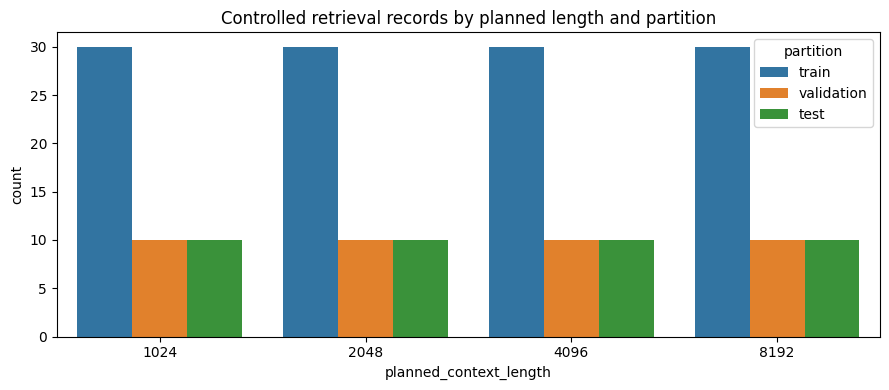

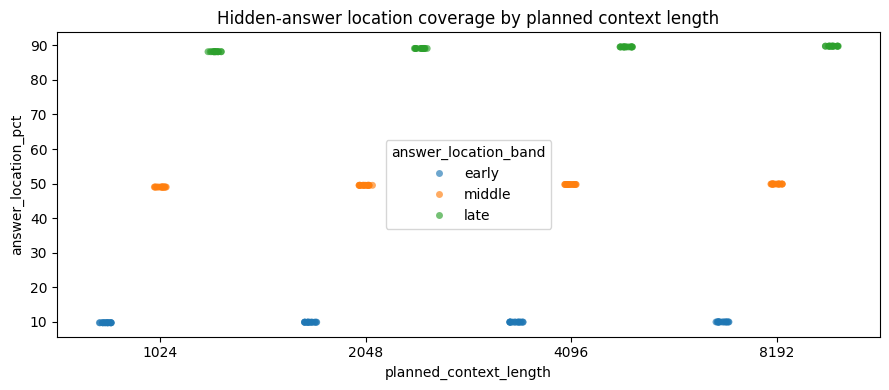

In [6]:
# Canonical controlled RULER-like corpus: 200 records, four length strata, exact 30/10/10 split per stratum.
rows = load_controlled_retrieval(tokenizer=tokenizer, seed=590)
corpus_audit = audit_controlled_retrieval_corpus(rows)
assert corpus_audit['passed'], corpus_audit
write_json(run_root / 'checks' / 'controlled_corpus_quality_audit.json', corpus_audit)
build_benchmark_manifest(
    rows, run_root / 'manifests' / 'controlled_retrieval_rows.json',
    benchmark_name='controlled_retrieval', seed=590,
    tokenizer_id=model_spec(profile.model_tier)['tokenizer_id'],
    tokenizer_revision=model_spec(profile.model_tier)['tokenizer_revision'],
    model_id=model_spec(profile.model_tier)['model_id'],
    model_revision=model_spec(profile.model_tier)['revision'],
)
eda = pd.DataFrame([{
    'benchmark': row['benchmark'], 'task': row['task'], 'row_id': row['row_id'],
    'partition': row['partition'], 'planned_context_length': row['planned_context_length'],
    'measured_context_length': row['measured_context_length'],
    'answer_location_band': row['answer_location_band'], 'answer_location_pct': row['answer_location_pct'],
    'characters': len(row['prompt']), 'answer_count': len(row.get('answers', [])),
    'tokens': int(row['measured_context_length']),
} for row in rows])
eda.to_csv(run_root / 'results' / 'controlled_retrieval_inventory.csv', index=False)
display(eda.groupby(['planned_context_length', 'partition']).agg(rows=('row_id','count'), median_tokens=('tokens','median'), max_tokens=('tokens','max')).reset_index())
plt.figure(figsize=(9,4)); sns.countplot(data=eda, x='planned_context_length', hue='partition', order=sorted(eda['planned_context_length'].unique())); plt.title('Controlled retrieval records by planned length and partition'); plt.tight_layout(); plt.savefig(run_root / 'figures' / 'eda_records_by_length_partition.png', dpi=180); plt.show()
plt.figure(figsize=(9,4)); sns.stripplot(data=eda, x='planned_context_length', y='answer_location_pct', hue='answer_location_band', dodge=True, alpha=0.65); plt.title('Hidden-answer location coverage by planned context length'); plt.tight_layout(); plt.savefig(run_root / 'figures' / 'eda_answer_position_coverage.png', dpi=180); plt.show()


## Step 3A: Report-Aligned Controlled-Corpus Visualizations

The following plots are computed only from the canonical 200-record controlled retrieval corpus loaded above. They reproduce the data-audit views included in the capstone report: split balance by planned context length, answer-location coverage, and numeric-relationship diagnostics. These are **EDA artifacts**, not model-quality or eviction-performance results.

All charts are saved in the run directory so the report figures can be regenerated from the same deterministic corpus manifest.


In [ ]:
# Report-aligned EDA visualizations: computed only from the 200-record controlled corpus.
EDA_PARTITION_ORDER = ['train', 'validation', 'test']
EDA_PALETTE = {'train': '#4C72B0', 'validation': '#DD8452', 'test': '#55A868'}
eda_viz = eda.copy()
eda_viz['partition'] = pd.Categorical(eda_viz['partition'], categories=EDA_PARTITION_ORDER, ordered=True)
eda_viz['length_drift_pct'] = (
    (eda_viz['measured_context_length'] - eda_viz['planned_context_length'])
    / eda_viz['planned_context_length'] * 100.0
)

# Gate the visualizations to the same deterministic corpus invariants documented in the report.
assert len(eda_viz) == 200, f'Expected 200 corpus records; found {len(eda_viz)}.'
split_counts = (
    eda_viz.groupby(['planned_context_length', 'partition'], observed=False)
    .size().rename('records').reset_index()
)
expected_split = {'train': 30, 'validation': 10, 'test': 10}
for _, item in split_counts.iterrows():
    assert int(item['records']) == expected_split[str(item['partition'])], item.to_dict()

# Figure A: records by planned context length and data partition.
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(
    data=split_counts, x='planned_context_length', y='records', hue='partition',
    order=sorted(eda_viz['planned_context_length'].unique()), hue_order=EDA_PARTITION_ORDER,
    palette=EDA_PALETTE, errorbar=None
)
ax.set(title='Records by Planned Context Length and Data Partition',
       xlabel='Planned context length (tokens)', ylabel='Number of records', ylim=(0, 33))
plt.tight_layout()
plt.savefig(run_root / 'figures' / 'eda_records_by_length_partition_report_aligned.png', dpi=180, bbox_inches='tight')
plt.show()

# Figure B: answer-location coverage as a percentage through the planned context.
plt.figure(figsize=(10, 5.5))
ax = sns.histplot(
    data=eda_viz, x='answer_location_pct', hue='partition', hue_order=EDA_PARTITION_ORDER,
    bins=np.linspace(0, 100, 11), multiple='stack', palette=EDA_PALETTE,
    edgecolor='white', linewidth=0.8
)
ax.set(title='Coverage of Answer Location within the Context',
       xlabel='Answer location (% through context)', ylabel='Number of records')
plt.tight_layout()
plt.savefig(run_root / 'figures' / 'eda_answer_location_coverage_report_aligned.png', dpi=180, bbox_inches='tight')
plt.show()

# Figure C: Spearman relationships among corpus design variables.
correlation_frame = eda_viz[[
    'planned_context_length', 'measured_context_length', 'answer_location_pct', 'length_drift_pct'
]].rename(columns={
    'planned_context_length': 'Planned context length',
    'measured_context_length': 'Measured context length',
    'answer_location_pct': 'Answer location',
    'length_drift_pct': 'Length drift (percentage)',
})
spearman_corr = correlation_frame.corr(method='spearman')
plt.figure(figsize=(9, 7.5))
ax = sns.heatmap(
    spearman_corr, annot=True, fmt='.2f', cmap='vlag', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Spearman rank correlation'}
)
ax.set_title('Relationships Among Numeric Dataset Variables', pad=14, weight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(run_root / 'figures' / 'eda_numeric_relationships_spearman_report_aligned.png', dpi=180, bbox_inches='tight')
plt.show()

# Persist the exact tables behind the plots for audit and report reproducibility.
split_counts.to_csv(run_root / 'results' / 'eda_context_partition_counts.csv', index=False)
spearman_corr.to_csv(run_root / 'results' / 'eda_numeric_spearman_correlations.csv')
eda_viz[[
    'row_id', 'partition', 'planned_context_length', 'measured_context_length',
    'answer_location_band', 'answer_location_pct', 'length_drift_pct'
]].to_csv(run_root / 'results' / 'eda_report_aligned_numeric_inventory.csv', index=False)
write_json(run_root / 'checks' / 'eda_report_aligned_visualizations.json', {
    'status': 'observed_controlled_corpus_eda',
    'records': int(len(eda_viz)),
    'planned_context_lengths': [int(v) for v in sorted(eda_viz['planned_context_length'].unique())],
    'partition_counts': {str(k): int(v) for k, v in eda_viz['partition'].value_counts().sort_index().items()},
    'figures': [
        'eda_records_by_length_partition_report_aligned.png',
        'eda_answer_location_coverage_report_aligned.png',
        'eda_numeric_relationships_spearman_report_aligned.png',
    ],
})
display(split_counts)
display(spearman_corr.round(3))


## Step 4: Measured Cache-Growth Trace

Finally, let us observe how the physical cache payload grows as the token prefix increases. This short trace supports our capacity planning for the larger GPUs later.

### What to Look For
Verify that the `payload_bytes` increases linearly with the `physical_length`. This confirms our memory footprint behaves as expected before we start evicting tokens.


In [7]:
lengths = [min(n, probe.shape[-1]) for n in (64, 128, 256, probe.shape[-1])]
growth = []
for length in sorted(set(lengths)):
    c, _ = prefill(model, probe[:, :length], chunk_size=min(256, length), output_attentions=False)
    growth.append({'tokens': int(length), 'payload_bytes': int(measured_cache_bytes(c)), 'physical_length': int(c.physical_length)})
pd.DataFrame(growth).to_csv(run_root / 'results' / 'observed_cache_growth.csv', index=False)
display(pd.DataFrame(growth))


,tokens,payload_bytes,physical_length
0,64,1835008,64
1,128,3670016,128
2,161,4616192,161


In [8]:
print('Foundations completed. Artifacts:', run_root)

# Result tables only contain observed rows, explicit errors, or explicit hardware requirement statuses.
# No cell manufactures latency, memory, or quality values. Preserve run_root for the Results section.


Foundations completed. Artifacts: kv_eviction_00_foundations_environment_eda


In [12]:
from google.colab import drive
from pathlib import Path
import shutil

# Mount only after you have reviewed the notebook and are ready to copy your own artifacts.
drive.mount('/content/drive')

DRIVE_BASE = Path('/content/drive/MyDrive/KV_Eviction_Capstone/02_notebook_runs')
NOTEBOOK_DRIVE_FOLDER = '00_foundations_run'  # Change for each notebook.

target = DRIVE_BASE / NOTEBOOK_DRIVE_FOLDER / run_root.name
if target.exists():
    raise FileExistsError(f'Refusing to overwrite an existing run: {target}')

target.parent.mkdir(parents=True, exist_ok=True)
shutil.copytree(run_root, target)
print(f'Copied complete run to: {target}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied complete run to: /content/drive/MyDrive/KV_Eviction_Capstone/02_notebook_runs/00_foundations_run/kv_eviction_00_foundations_environment_eda
